# IMPOR LIBRARY
Kode diatas digunakan untuk mengimpor library yang diperlukan dalam pengolahan citra dan visualisasi. `cv2` untuk operasi citra, `pandas` untuk pengolahan data, `matplotlib.pyplot` untuk menampilkan gambar dan histogram, serta `numpy` untuk operasi numerik dan manipulasi array.

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

# SIMPAN DAN PRINT GAMBAR 
Kode di atas merupakan kode untuk membaca gambar yang ada pada file kita,  plt.imread adalah fungsi untuk menyimpan gambar dimana `backup.jpg` disimpan dalam sebuah variabel agar memudahkan pemanggilan

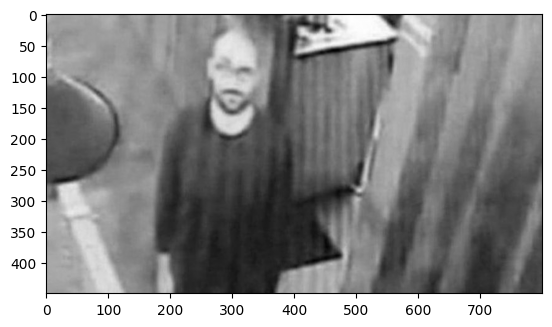

In [2]:
CCTVImage = cv2.imread('backup.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(CCTVImage, cmap='gray')

# DEFINISI KERNEL KONVOLUSI DAN DETEKSI TEPI

Cell ini mendefinisikan enam jenis kernel yang akan digunakan untuk pengolahan citra. Kernel adalah matriks kecil berisi angka-angka yang akan dikalikan dengan nilai piksel tetangga untuk menghasilkan efek pemrosesan tertentu melalui proses konvolusi. Kernel `Smoothing` mengurangi noise dengan merata-ratakan piksel, `Sharpening` meningkatkan tepi dengan memperkuat piksel pusat, sementara `Sobel`, `Prewitt`, dan `Roberts` digunakan untuk mendeteksi tepi citra pada arah horizontal, vertikal, dan diagonal. Kernel-kernel ini menjadi fondasi untuk cell selanjutnya karena akan digunakan oleh fungsi `convolution()` untuk smoothing dan sharpening citra, fungsi `edge()` untuk mendeteksi tepi, serta hasil deteksi tepi akan menjadi dasar pembuatan mask untuk menonjolkan objek manusia dalam citra CCTV.

In [3]:
Smoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

Sharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

# KONVOLUSI DAN FILTERING

Cell ini mengimplementasikan fungsi `convolution()` untuk menerapkan kernel pada citra melalui proses penggandaan elemen dan penjumlahan, serta fungsi `filter()` yang mendukung tiga mode filtering yaitu `mean`, `median`, dan `modus` untuk mengurangi noise. Proses berlangsung dengan menempatkan kernel di setiap piksel, mengalikan nilai-nilainya dengan piksel tetangga, kemudian menjumlahkan hasilnya untuk mendapatkan nilai output baru, sedangkan filtering menggunakan jendela geser yang sama untuk merata-ratakan, mencari nilai tengah, atau mencari nilai paling sering pada area tetangga. Hasil pemrosesan ini berupa citra yang sudah dihalus (smoothing), ditajamkan (sharpening), atau dikombinasikan, serta hasil filtering dengan berbagai ukuran kernel yang akan menjadi input penting untuk deteksi tepi pada cell selanjutnya.

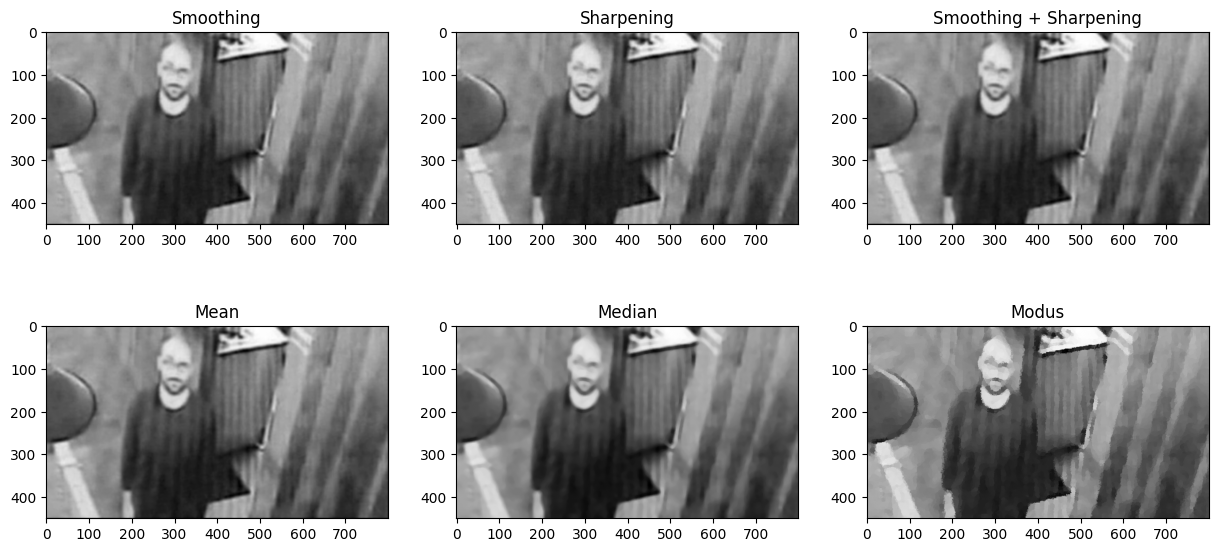

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

CCTVImage_Smoothing = convolution(CCTVImage, Smoothing)
CCTVImage_Sharpening = convolution(CCTVImage, Sharpening)
CCTVImage_Double = convolution(CCTVImage_Smoothing, Sharpening)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        # MEAN FILTER
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    mean = np.sum(region) / area
                    canvas[i, j] = mean

        # MEDIAN FILTER
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    median = np.median(region)
                    canvas[i, j] = median

        # MODE / MODUS FILTER
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

CCTVMean = filter(CCTVImage_Smoothing, 3, 'mean')
CCTVMedian = filter(CCTVImage, 9, 'median')
CCTVModus = filter(CCTVImage, 9, 'modus')

plt.figure(figsize=(15, 7))

plt.subplot(2, 3, 1)
plt.title("Smoothing")
plt.imshow(CCTVImage_Smoothing, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("Sharpening")
plt.imshow(CCTVImage_Sharpening, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("Smoothing + Sharpening")
plt.imshow(CCTVImage_Double, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("Mean")
plt.imshow(CCTVMean, cmap='gray')

plt.subplot(2, 3, 5)
plt.title("Median")
plt.imshow(CCTVMedian, cmap='gray')

plt.subplot(2, 3, 6)
plt.title("Modus")
plt.imshow(CCTVModus, cmap='gray')

plt.show()

# ANALISIS PENGGUNAAN FILTER BERBEDA
berdasarkan gambar diatas, perbedaannya memang tipis banget karena kualitas fotonya rendah. Tapi secara teori, Smoothing itu bikin gambar  burem biar bintik-bintik kotornya hilang, sedangkan Sharpening justru bikin garis-garis tepi jadi lebih tegas biar objeknya lebih terlihat. kalau gabungan itu ibaratnya dibersihin dulu kotorannya sampai mulus, baru kemudian ditebelin lagi garis-garis pentingnya biar hasilnya kelihatan lebih rapi dan jelas di mata.

# DETEKSI TEPI DENGAN SOBEL, PREWITT, DAN ROBERTS

Cell ini mengimplementasikan fungsi `edge()` untuk mendeteksi tepi citra menggunakan tiga operator deteksi tepi yaitu `Sobel`, `Prewitt`, dan `Roberts`, serta fungsi `normalize()` untuk menormalisasi nilai piksel. Proses berlangsung dengan menerapkan kedua kernel horizontal dan vertikal dari setiap operator pada citra yang sudah difilter, menghitung nilai absolut dari kedua arah, kemudian menjumlahkan dan menormalisasi hasilnya ke rentang 0-255. Selain menerapkan ketiga operator secara terpisah, cell ini juga membuat kombinasi operator seperti `Prewitt + Sobel`, `Prewitt + Roberts`, `Sobel + Roberts`, dan `Prewitt + Sobel + Roberts` untuk membandingkan hasil deteksi. Hasil deteksi tepi dari ketiga operator ini akan menjadi dasar untuk cell selanjutnya dalam membuat mask dan menonjolkan objek manusia pada citra CCTV.

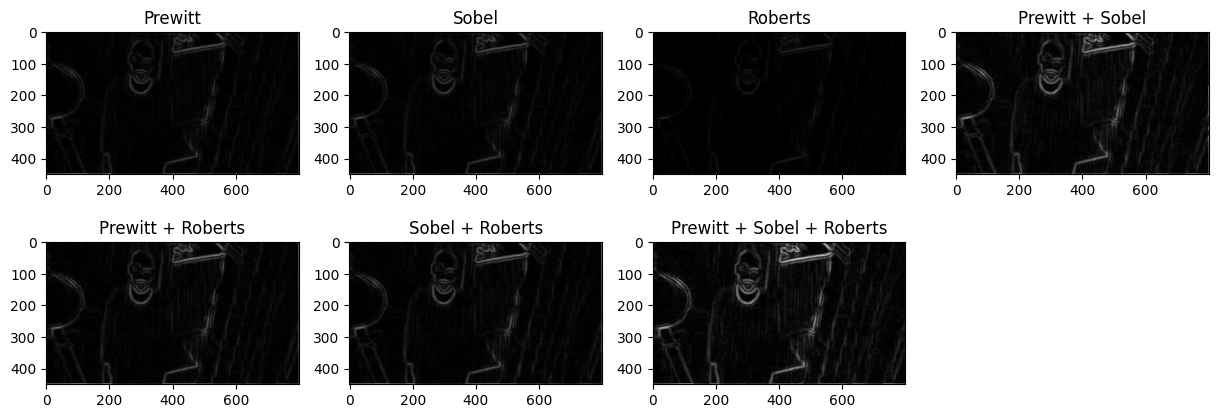

In [5]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def normalize(img):
    img = img.astype(np.float32)
    return (img * 255.0 / np.max(img)).astype(np.uint8)

CCTVPrewitt = edge(CCTVMean, prewittX, prewittY)
CCTVSobel = edge(CCTVMean, sobelX, sobelY)
CCTVRobert = edge(CCTVMean, robertsX, robertsY)

CCTVPreso = normalize(CCTVPrewitt + CCTVSobel)
CCTVPrebert = normalize(CCTVPrewitt + CCTVRobert)
CCTVSobert = normalize(CCTVSobel + CCTVRobert)

CCTVMix = normalize(CCTVPrewitt + CCTVSobel + CCTVRobert)

plt.figure(figsize=(15, 5)) 

plt.subplot(2, 4, 1) 
plt.title("Prewitt") 
plt.imshow(CCTVPrewitt, cmap='gray')

plt.subplot(2, 4, 2) 
plt.title("Sobel") 
plt.imshow(CCTVSobel, cmap='gray') 

plt.subplot(2, 4, 3) 
plt.title("Roberts") 
plt.imshow(CCTVRobert, cmap='gray') 

plt.subplot(2, 4, 4) 
plt.title("Prewitt + Sobel") 
plt.imshow(CCTVPreso, cmap='gray') 

plt.subplot(2, 4, 5) 
plt.title("Prewitt + Roberts") 
plt.imshow(CCTVPrebert, cmap='gray') 

plt.subplot(2, 4, 6) 
plt.title("Sobel + Roberts") 
plt.imshow(CCTVSobert, cmap='gray') 

plt.subplot(2, 4, 7) 
plt.title("Prewitt + Sobel + Roberts") 
plt.imshow(CCTVMix, cmap='gray') 
plt.show()

# ANALISIS DETEKSI TEPI
Gambar tersebut memperlihatkan perbandingan hasil deteksi tepi menggunakan operator Prewitt, Sobel, Roberts, serta kombinasi ketiganya. Operator Prewitt menghasilkan tepi yang cukup halus namun detailnya tidak terlalu kuat, sedangkan Sobel memberikan tepi yang lebih jelas karena memiliki sensitivitas lebih tinggi terhadap perubahan intensitas. Operator Roberts menghasilkan garis tepi yang lebih tipis dan tajam, tetapi juga lebih sensitif terhadap noise karena menggunakan kernel berukuran kecil. Pada kombinasi operator seperti Prewitt + Sobel atau Sobel + Roberts, detail tepi terlihat lebih lengkap karena informasi gradien dari masing-masing operator digabungkan. Kombinasi Prewitt + Sobel + Roberts menghasilkan tepi paling detail dan kontras, namun juga meningkatkan jumlah noise dan tekstur yang ikut terdeteksi. Hal ini menunjukkan bahwa penggabungan beberapa operator dapat memperkaya informasi tepi, tetapi perlu pengaturan threshold atau filtering tambahan agar hasil tetap bersih dan fokus pada objek utama.

# THRESHOLDING

Cell ini menjelaskan bagaimana `threshold` digunakan untuk mengubah hasil deteksi tepi menjadi `mask` biner dengan nilai 0 dan 255, serta menunjukkan bahwa `threshold` rendah akan menangkap area yang lebih luas sementara `threshold` tinggi hanya mempertahankan tepi paling kuat; pemahaman ini penting karena pilihan `threshold` akan mempengaruhi kualitas `mask` yang dipakai pada cell selanjutnya untuk menonjolkan objek manusia.

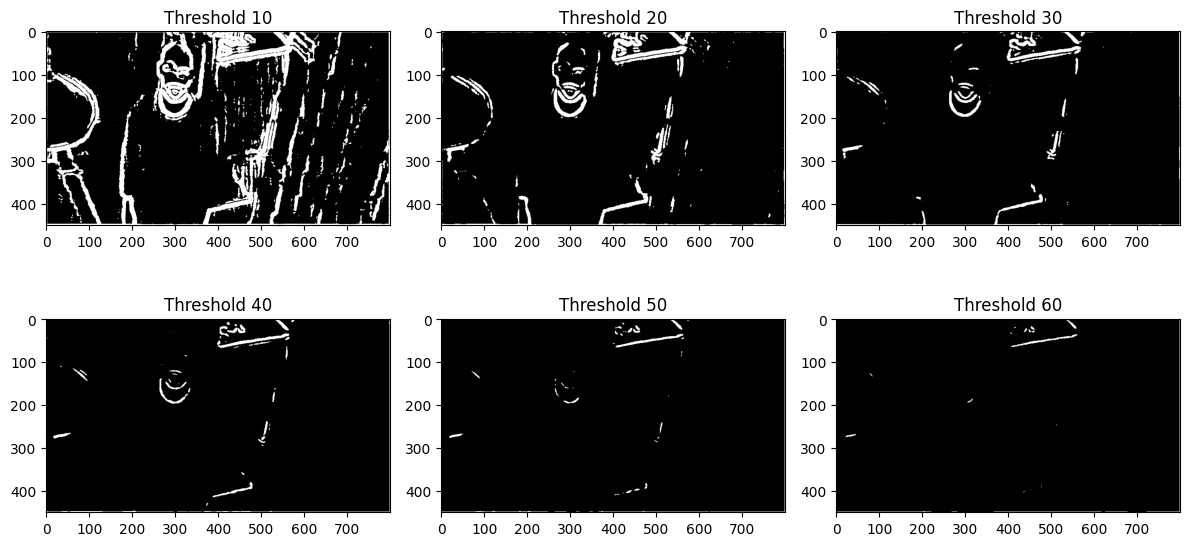

In [6]:
def threshold_edge(img, threshold):
    canvas = np.zeros_like(img)

    canvas[img >= threshold] = 255
    canvas[img < threshold] = 0

    return canvas.astype(np.uint8)

Threshold10 = threshold_edge(CCTVSobel, 10)
Threshold20 = threshold_edge(CCTVSobel, 20)
Threshold30 = threshold_edge(CCTVSobel, 30)
Threshold40 = threshold_edge(CCTVSobel, 40)
Threshold50 = threshold_edge(CCTVSobel, 50)
Threshold60 = threshold_edge(CCTVSobel, 60)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.title("Threshold 10")
plt.imshow(Threshold10, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("Threshold 20")
plt.imshow(Threshold20, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("Threshold 30")
plt.imshow(Threshold30, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("Threshold 40")
plt.imshow(Threshold40, cmap='gray')

plt.subplot(2, 3, 5)
plt.title("Threshold 50")
plt.imshow(Threshold50, cmap='gray')

plt.subplot(2, 3, 6)
plt.title("Threshold 60")
plt.imshow(Threshold60, cmap='gray')

plt.tight_layout()
plt.show()

# ANALISIS PENGGUNAAN THRESHOLD
Gambar tersebut menunjukkan pengaruh nilai threshold terhadap hasil deteksi tepi pada citra. Pada threshold 10, hampir seluruh detail dan noise masih terdeteksi sehingga garis tepi terlihat sangat banyak dan kurang bersih. Ketika nilai threshold dinaikkan menjadi 20 dan 30, noise mulai berkurang dan hanya bagian tepi dengan intensitas lebih kuat yang tetap muncul sehingga objek utama terlihat lebih jelas. Pada threshold 40 hingga 60, proses seleksi menjadi semakin ketat sehingga sebagian besar detail halus menghilang dan hanya tepi dengan kontras tinggi yang tersisa. Hal ini menunjukkan bahwa semakin besar nilai threshold, semakin sedikit piksel yang dianggap sebagai tepi, sehingga hasil menjadi lebih bersih namun berisiko kehilangan detail penting pada objek.

# MASKING ORANG
Code dibawah ini melakukan proses segmentasi dan peningkatan area objek menggunakan teknik thresholding, median filter, dilasi, serta edge detection. Awalnya program membuat mask berdasarkan rentang intensitas piksel tertentu pada area yang sudah ditentukan menggunakan koordinat (x1, y1) dan (x2, y2). Setelah itu dilakukan proses pembersihan noise menggunakan pemeriksaan jumlah tetangga aktif dan median_filter() agar area objek menjadi lebih halus. Proses dilate() kemudian memperbesar area objek sehingga bagian yang terdeteksi menjadi lebih menyatu. Setelah mask dibinerisasi kembali menjadi 0 dan 255, dilakukan deteksi tepi menggunakan fungsi edge() dengan kernel Sobel untuk menghasilkan outline. Hasil akhir pada variabel hasil diperoleh dengan memodifikasi warna area yang berada di dalam mask serta memberi efek garis tepi berdasarkan nilai outline. Output dari cell ini digunakan untuk menampilkan visualisasi akhir berupa mask, hasil edge detection, dan citra yang sudah diberi efek warna sehingga proses segmentasi objek terlihat lebih jelas.

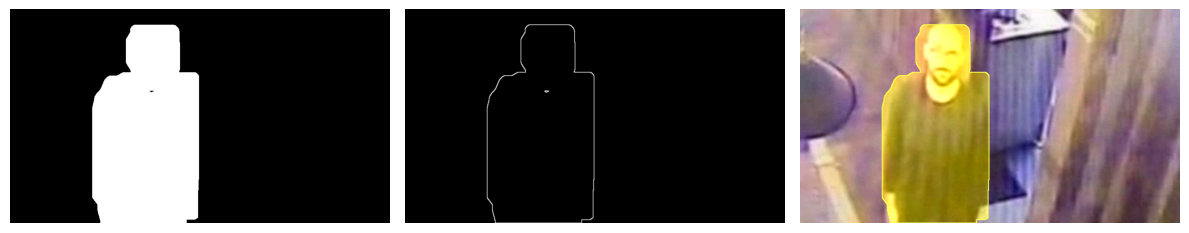

In [7]:
img = cv2.imread("backup.jpg")
backuprgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
backup = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def median_filter(img, size):
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    h, w = img.shape
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            result[i, j] = np.median(region)
    return result

def dilate(img, size):
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    h, w = img.shape
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            result[i, j] = np.max(region)
    return result

tinggi, lebar = backup.shape
mask = np.zeros((tinggi, lebar), dtype=np.uint8)

x1, y1 = 190, 50
x2, y2 = 380, 450

for i in range(tinggi):
    for j in range(lebar):
        if y1 <= i <= y2 and x1 <= j <= x2:
            if i < 150:
                if 220 <= j <= 340:
                    if 170 < backup[i, j] < 245:
                        mask[i, j] = 255
            else:
                if 45 < backup[i, j] < 110:
                    mask[i, j] = 255

mask_baru = np.zeros_like(mask)
for i in range(1, tinggi-1):
    for j in range(1, lebar-1):
        jumlah = 0
        for a in range(-1, 2):
            for b in range(-1, 2):
                if mask[i+a, j+b] == 255:
                    jumlah += 1
        if jumlah >= 5:
            mask_baru[i, j] = 255
mask = mask_baru

mask = median_filter(mask, 15)
mask = dilate(mask, 35)

for i in range(tinggi):
    for j in range(lebar):
        if mask[i, j] > 127:
            mask[i, j] = 255
        else:
            mask[i, j] = 0

outline = edge(mask, sobelX, sobelY)
hasil = backuprgb.copy()

for i in range(tinggi):
    for j in range(lebar):
        if mask[i, j] == 255:
            hasil[i, j, 0] = min(255, int(hasil[i, j, 0]) + 80)
            hasil[i, j, 1] = min(255, int(hasil[i, j, 1]) + 80)
            hasil[i, j, 2] = max(0, int(hasil[i, j, 2]) - 60)
        if outline[i, j] > 80:
            hasil[i, j, 0] = 255
            hasil[i, j, 1] = 255
            hasil[i, j, 2] = 80

plt.figure(figsize=(12, 6))

plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(outline, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.axis('off')

plt.tight_layout()
plt.show()

# ANALISIS MASKING MANUSIA 
Gambar tersebut menunjukkan tahapan segmentasi objek hingga pemberian efek visual pada hasil akhir. Citra pertama merupakan mask hasil segmentasi, di mana area objek berhasil dipisahkan dari latar belakang menggunakan proses thresholding, filtering, dan dilasi sehingga objek tampak berwarna putih penuh pada background hitam. Citra kedua adalah hasil edge detection yang menampilkan garis tepi objek menggunakan operator deteksi tepi sehingga bentuk objek terlihat lebih jelas melalui kontur tipis di sekelilingnya. Pada citra ketiga, mask dan outline diaplikasikan kembali ke citra asli sehingga area objek mendapatkan efek highlight berwarna kuning terang, sementara garis tepi diperkuat agar objek lebih menonjol dibandingkan background. Proses ini menunjukkan bagaimana segmentasi dan deteksi tepi dapat digabungkan untuk meningkatkan fokus visual terhadap objek utama pada citra.

# MASKING DAN PENGHAPUSAN LATAR BELAKANG

Cell ini membuat `mask` untuk memisahkan objek utama dari latar belakang dengan membandingkan nilai warna pada citra RGB dan kemudian membersihkan `mask` tersebut menggunakan `median_filter`, setelah itu area yang disaring digunakan untuk mempertahankan nilai warna asli pada objek dan mengganti latar belakang dengan warna putih; proses ini menyiapkan hasil akhir yang lebih jelas untuk menonjolkan objek manusia dan menunjukkan bagaimana `mask` yang dibuat sebelumnya berperan dalam pemisahan objek dari background.

C:\Users\andika azkiya\AppData\Local\Temp\ipykernel_12296\2659640401.py:24: RuntimeWarning: overflow encountered in scalar add
  if g[i,j] > r[i,j] + 20 and b[i,j] > r[i,j] + 20:


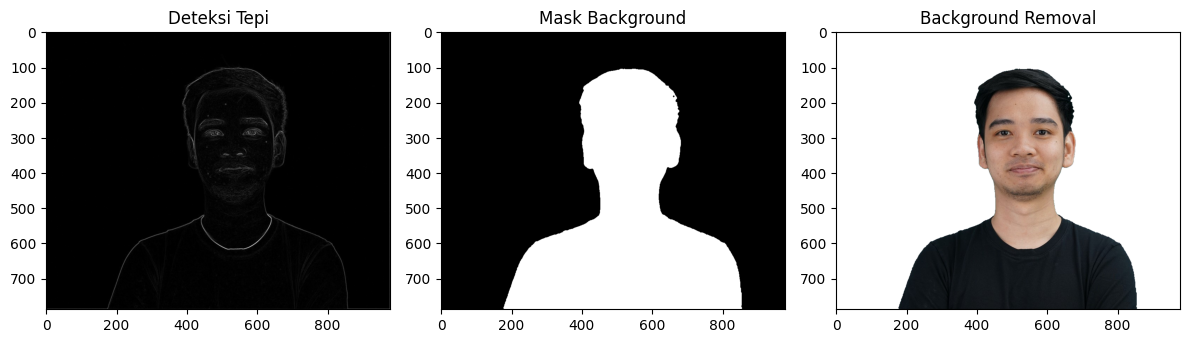

In [8]:
img = cv2.imread('david.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = (
    0.299 * imgRGB[:,:,0] +
    0.587 * imgRGB[:,:,1] +
    0.114 * imgRGB[:,:,2]
).astype(np.uint8)

edgeResult = edge(gray, sobelX, sobelY)

r = imgRGB[:,:,0]
g = imgRGB[:,:,1]
b = imgRGB[:,:,2]

mask = np.zeros(gray.shape, dtype=np.uint8)

h, w = gray.shape

for i in range(h):
    for j in range(w):

        # background toska
        if g[i,j] > r[i,j] + 20 and b[i,j] > r[i,j] + 20:
            mask[i,j] = 0

        else:
            mask[i,j] = 255

def median_filter(img, size):

    h, w = img.shape
    pad = size // 2

    padded = np.zeros((h + 2*pad, w + 2*pad))

    padded[pad:pad+h, pad:pad+w] = img

    output = np.zeros((h,w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):

            area = []

            for m in range(size):
                for n in range(size):

                    area.append(
                        padded[i+m, j+n]
                    )

            area.sort()

            output[i,j] = area[len(area)//2]

    return output

mask = median_filter(mask, 5)
result = np.ones_like(imgRGB) * 255

for i in range(h):
    for j in range(w):

        if mask[i,j] == 255:

            result[i,j,0] = imgRGB[i,j,0]
            result[i,j,1] = imgRGB[i,j,1]
            result[i,j,2] = imgRGB[i,j,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Deteksi Tepi")
plt.imshow(edgeResult, cmap='gray')

plt.subplot(1,3,2)
plt.title("Mask Background")
plt.imshow(mask, cmap='gray')

plt.subplot(1,3,3)
plt.title("Background Removal")
plt.imshow(result)

plt.tight_layout()
plt.show()